In [77]:
from sklearn.cluster import KMeans

import numpy as np
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.image import imread

%matplotlib inline
#Allows the output of plotting commands to be displayed within the notebook,
#directly below the code cell that produces them.
#The resulting plots are then stored in the notebook.
import warnings
warnings.simplefilter('ignore')

We generate 6000 two-dimensional random examples belonging to two data clusters with normal distribution. The first 3000 items will belong to the first data cloud, and the remaining 3000 to the second.

In [78]:
n_samples = 3000

X = np.concatenate((
    np.random.normal((-2, -2), size=(n_samples, 2)),
    np.random.normal((2, 2), size=(n_samples, 2))
))

X.shape

(6000, 2)

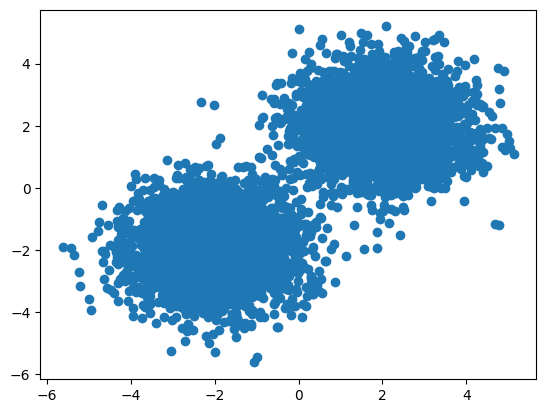

In [79]:
plt.scatter(X[:,0],X[:,1])
plt.show()

Let's apply K-means to these data. To do this we first create the estimator object. Scikit-learn provides objects called **Estimators** that allow you to learn from the data, hiding the implementation of the algorithm. It is a generic structure that is then specialized to solve classification, regression or clustering tasks.

All estimator objects expose a fit method that takes the dataset (usually a 2-d array) as input:

estimator.fit(data)

In [80]:
K=2
#We set the number of clusters (K) to 2 because we know that
#the data is grouped into 2 classes.

kmeans = KMeans(n_clusters=K, random_state=11)
#the random_state parameter makes the initialization of centroids deterministic
#by fixing the random number generated, so as to aid in the reproducibility
#of the experiment.

kmeans.fit(X)

KMeans(n_clusters=2, random_state=11)

As soon as a model is created using the estimator object, all estimated parameters are attributes of the estimator object and end with an underscore.
In case of KMeans, the returned object will contain the attributes:



*   labels_ that is an array containing the cluster labels associated with each element. It will have values from 0 to k-1 (k=number of clusters)
*   cluster_centers_ that is an array containing centroids (rows of the vector)

In [81]:
print('centroids', kmeans.cluster_centers_)

centroids [[-2.02681028 -1.98090962]
 [ 2.00909163  1.99322951]]


In [82]:
print(kmeans.labels_[0:50])
print(kmeans.labels_[1000:1050])

print(kmeans.labels_[3500:3550])
print(kmeans.labels_[5000:5050])

# Sum of squared distances of samples to their closest cluster center
print('SSE=',kmeans.inertia_)

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]
SSE= 11792.98979520079


We plot clusters and centroids

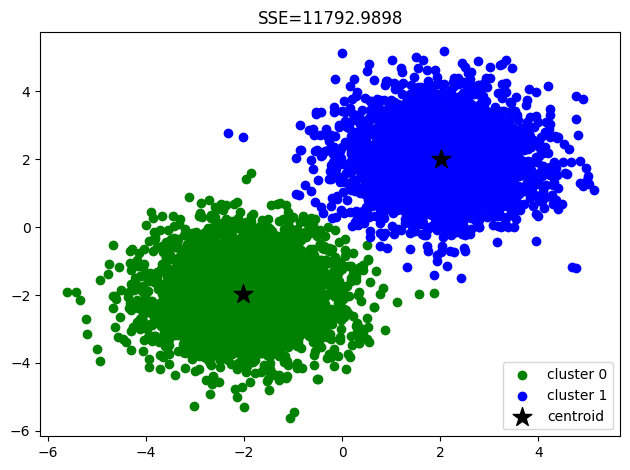

In [83]:
plt.scatter(X[kmeans.labels_== 0, 0], X[kmeans.labels_ == 0, 1],
                  c='green', label='cluster 0')
plt.scatter(X[kmeans.labels_== 1, 0], X[kmeans.labels_ == 1, 1],
                  c='blue', label='cluster 1')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                  c='black', marker='*', s=200, label='centroid')
plt.legend(loc='lower right')
plt.title('SSE=' f'{kmeans.inertia_:.4f}')
plt.tight_layout();

Let's consider a different data set

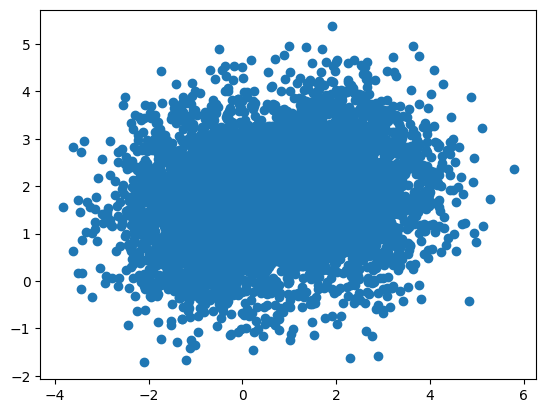

In [84]:
n_samples = 3000

X2 = np.concatenate((
    np.random.normal((-0.5, 1.5), size=(n_samples, 2)),
    np.random.normal((2, 2), size=(n_samples, 2))
))
plt.scatter(X2[:,0],X2[:,1])
plt.show()

In this case we dont't know a priori the number of clusters. Let's try with different values of K.

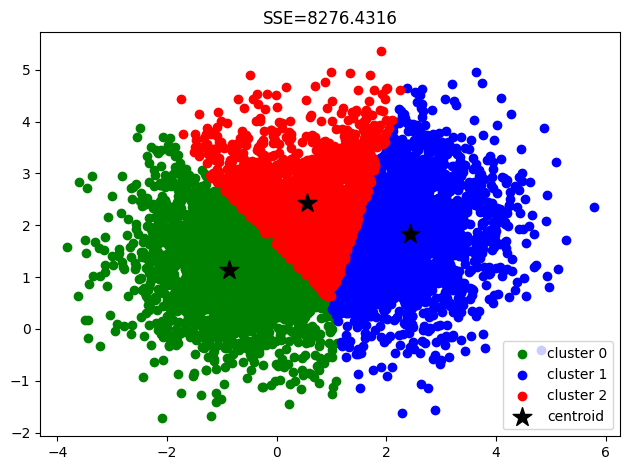

In [85]:
K=3
kmeans2 = KMeans(n_clusters=K, random_state=11)
#the random_state parameter makes the initialization of centroids deterministic
#by fixing the random number generated, so as to aid in the reproducibility
#of the experiment.

kmeans2.fit(X2)

# plot result
plt.scatter(X2[kmeans2.labels_== 0, 0], X2[kmeans2.labels_ == 0, 1],
                  c='green', label='cluster 0')
plt.scatter(X2[kmeans2.labels_== 1, 0], X2[kmeans2.labels_ == 1, 1],
                  c='blue', label='cluster 1')
plt.scatter(X2[kmeans2.labels_== 2, 0], X2[kmeans2.labels_ == 2, 1],
                  c='red', label='cluster 2')
plt.scatter(kmeans2.cluster_centers_[:, 0], kmeans2.cluster_centers_[:, 1],
                  c='black', marker='*', s=200, label='centroid')
plt.legend(loc='lower right')
plt.title('SSE=' f'{kmeans2.inertia_:.4f}')
plt.tight_layout();

Searching for the optimal number of clusters. Let's use the Elbow method, varying the value of K

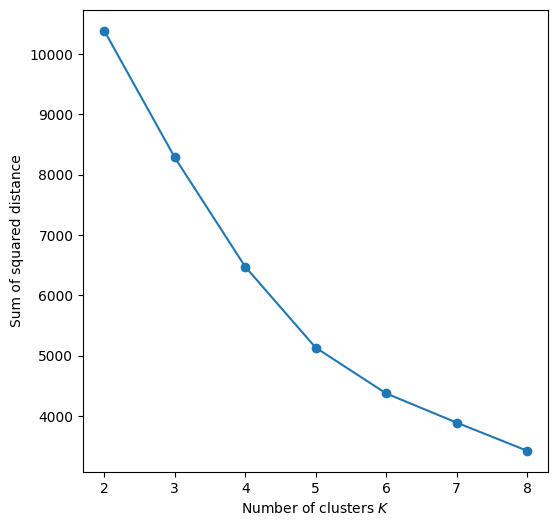

In [86]:
sse = []
k_list=list(range(2, 9))
for K in k_list:
    km = KMeans(n_clusters=K)
    km.fit(X2)
    sse.append(km.inertia_)

# Plot sse against K
plt.figure(figsize=(6, 6))
plt.plot(k_list, sse, '-o')
plt.xlabel(r'Number of clusters $K$')
plt.ylabel('Sum of squared distance');

Let's evaluate cluster quality using the silhouette index.

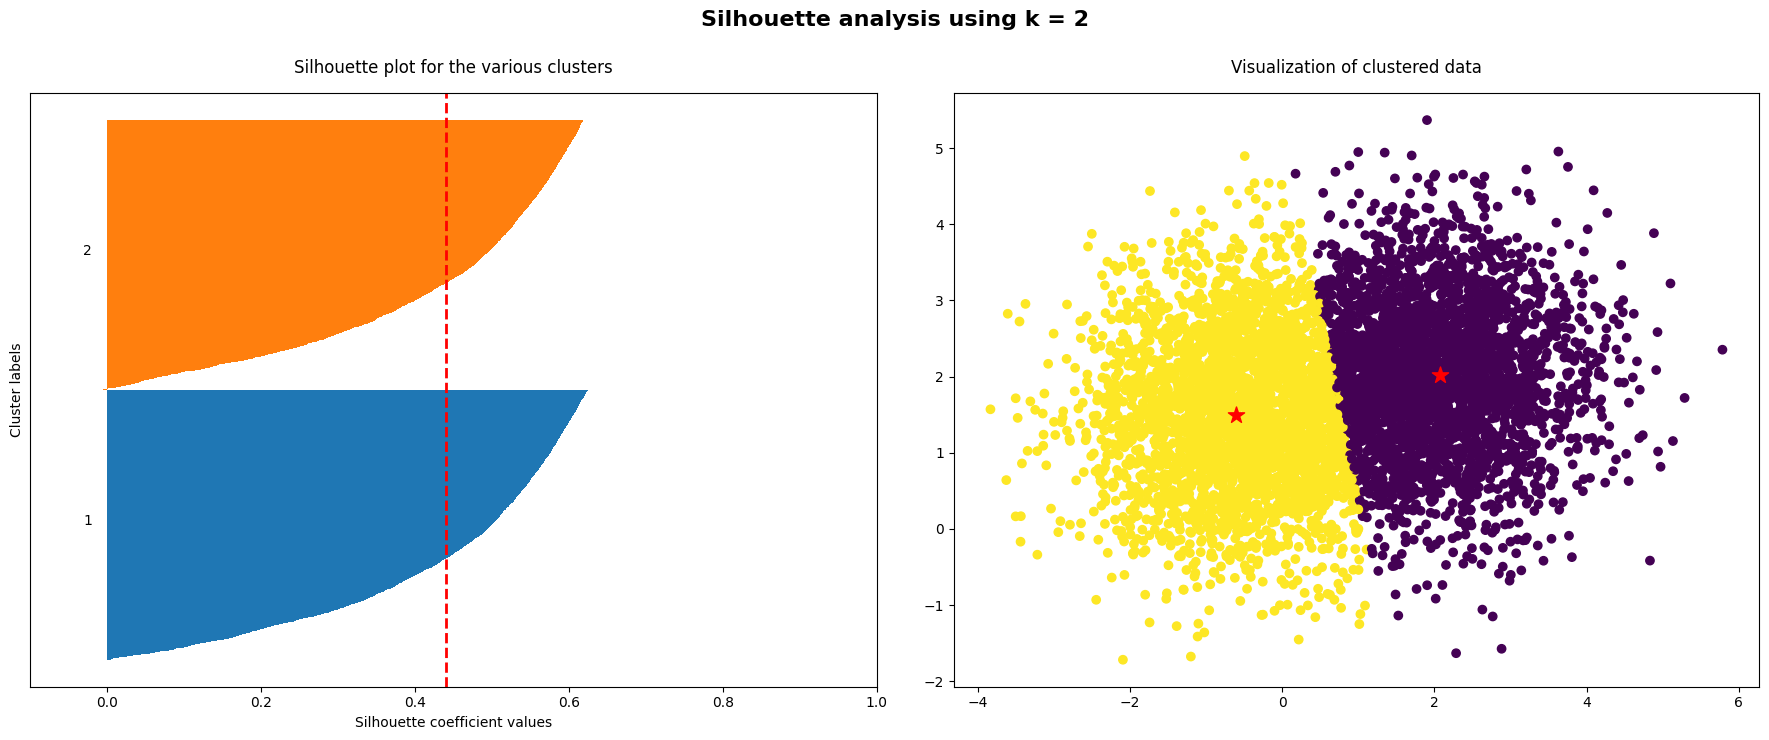

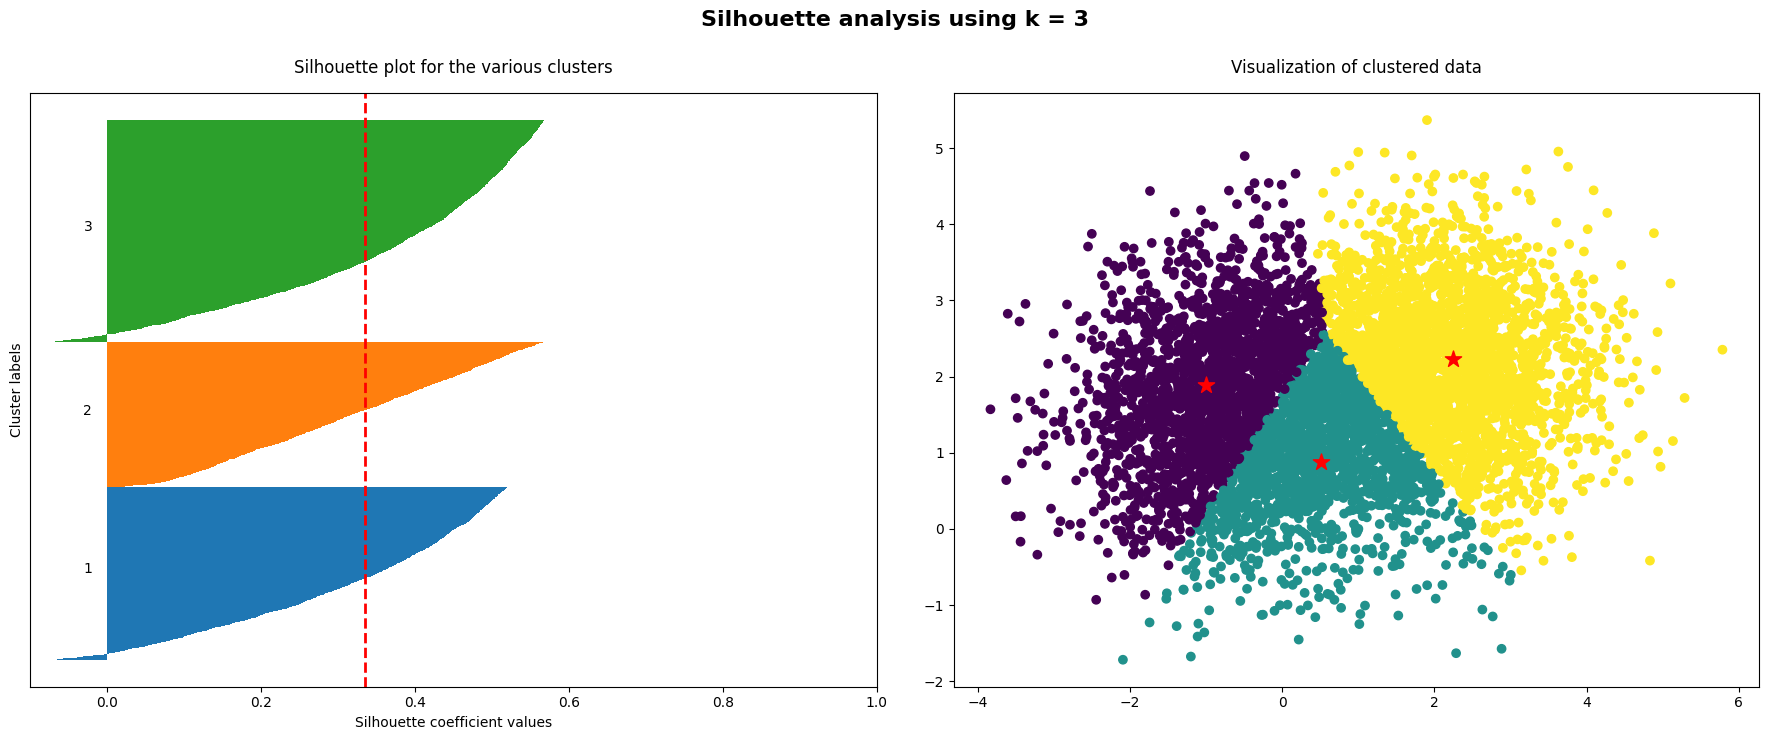

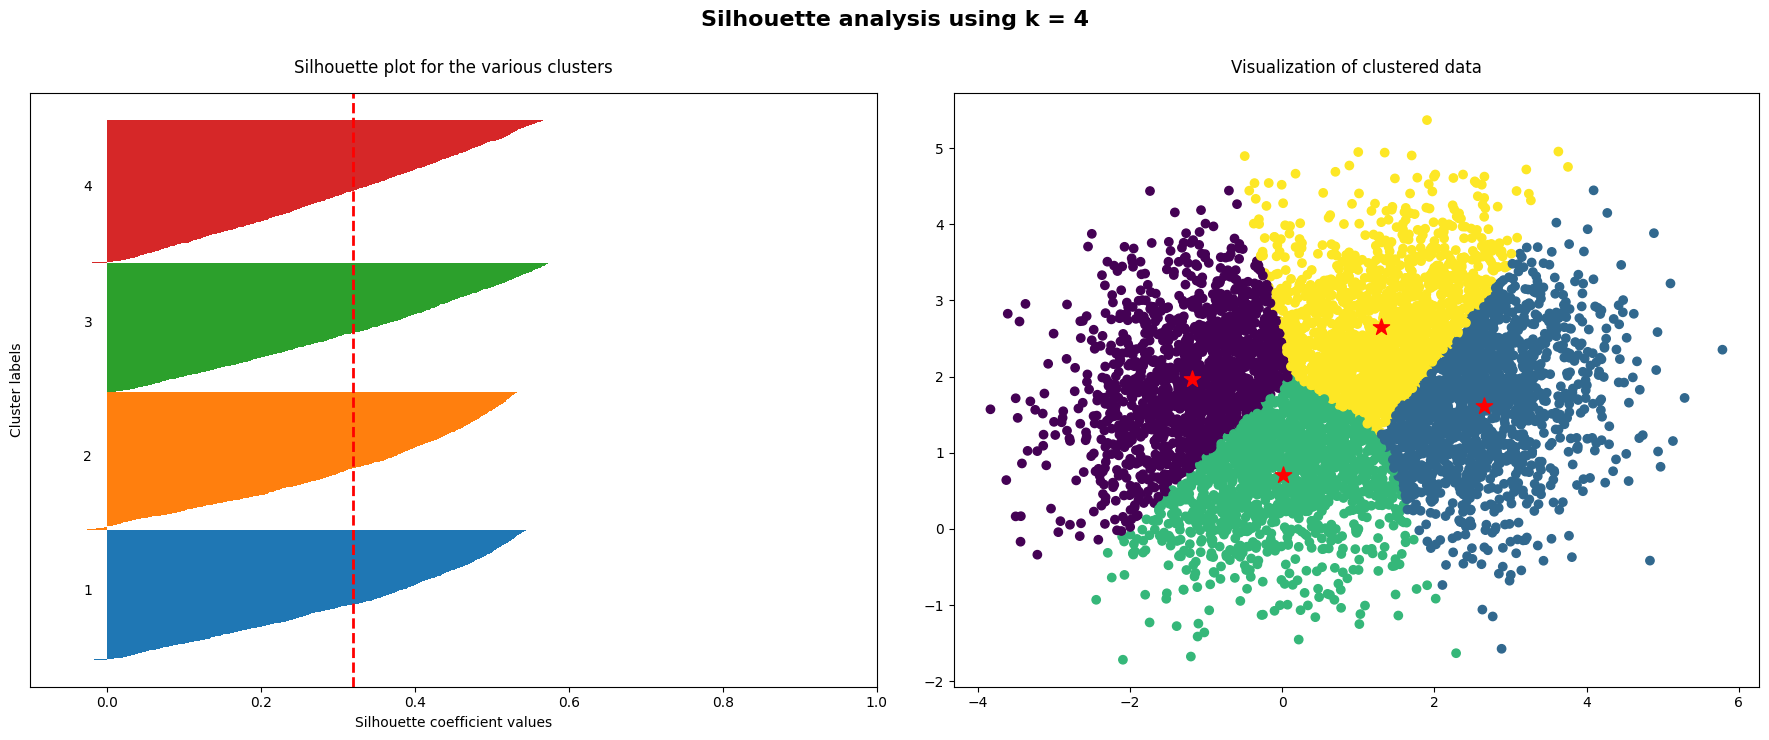

In [87]:
from sklearn.metrics import silhouette_samples, silhouette_score

for i, k in enumerate([2, 3, 4]):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # Run the Kmeans algorithm
    km = KMeans(n_clusters=k)
    labels = km.fit_predict(X2)
    centroids = km.cluster_centers_

    # Get silhouette samples
    silhouette_vals = silhouette_samples(X2, labels)

    # Silhouette plot
    y_ticks = []
    y_lower, y_upper = 0, 0
    for i, cluster in enumerate(np.unique(labels)):
        cluster_silhouette_vals = silhouette_vals[labels == cluster]
        cluster_silhouette_vals.sort()
        y_upper += len(cluster_silhouette_vals)
        ax1.barh(range(y_lower, y_upper), cluster_silhouette_vals, edgecolor='none', height=1)
        ax1.text(-0.03, (y_lower + y_upper) / 2, str(i + 1))
        y_lower += len(cluster_silhouette_vals)

    # Get the average silhouette score and plot it
    avg_score = np.mean(silhouette_vals)
    ax1.axvline(avg_score, linestyle='--', linewidth=2, color='red')
    ax1.set_yticks([])
    ax1.set_xlim([-0.1, 1])
    ax1.set_xlabel('Silhouette coefficient values')
    ax1.set_ylabel('Cluster labels')
    ax1.set_title('Silhouette plot for the various clusters', y=1.02);

    # Scatter plot of data colored with labels
    ax2.scatter(X2[:, 0], X2[:, 1], c=labels)
    ax2.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='r', s=150)
    #ax2.set_xlim([-2, 2])
    #ax2.set_xlim([-2, 2])
    ax2.set_title('Visualization of clustered data', y=1.02)
    ax2.set_aspect('equal')
    plt.tight_layout()
    plt.suptitle(f'Silhouette analysis using k = {k}',
                 fontsize=16, fontweight='semibold', y=1.05);

## Kmeans for Color quantization

In [88]:
import numpy as np
import cv2
from PIL import Image
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.image import imread

Number of pixels =  312130
Number of colors =  43143


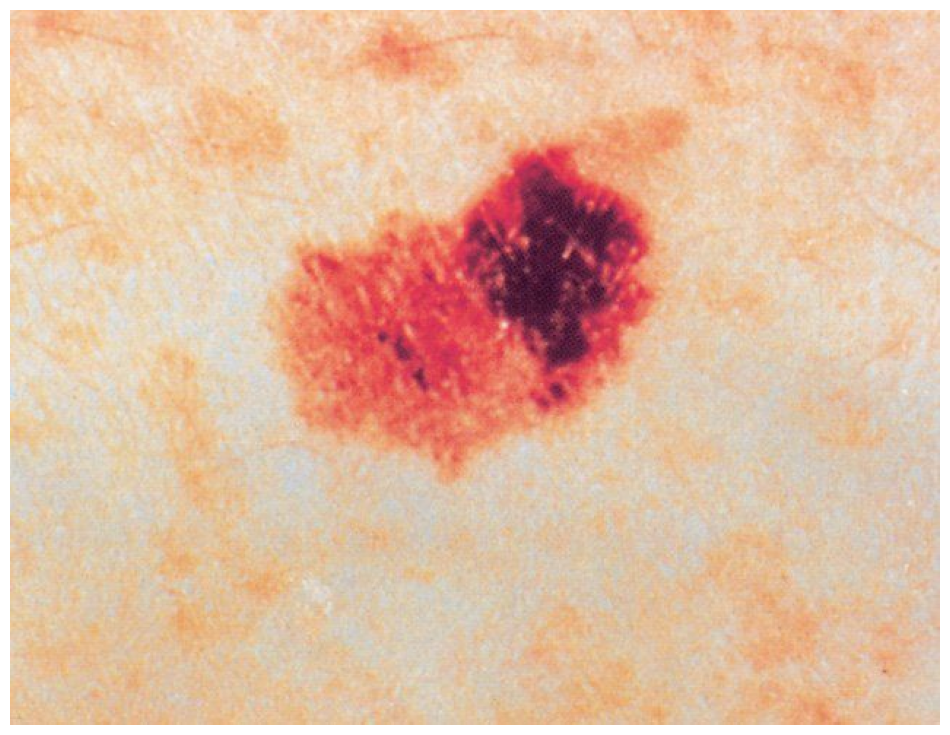

In [89]:
# Read the image
#img = imread('skin.jpeg')
#img = imread('oarsman.jpeg') # taken from https://omadson.github.io/photos/
#plt.imshow(img)
#print(img.shape)
I = Image.open('skin.jpeg')
#I = Image.open('oarsman.jpeg')
w, h = I.size
colors = I.getcolors(w * h)
num_colors = len(colors)
num_pixels = w*h

print ('Number of pixels = ', num_pixels)
print ('Number of colors = ', num_colors)

#We transform it into a numpy array
img = np.asarray(I,dtype=np.float32)/255
plt.figure(figsize=(12,12))
plt.imshow(img)
plt.axis('off')
plt.show()

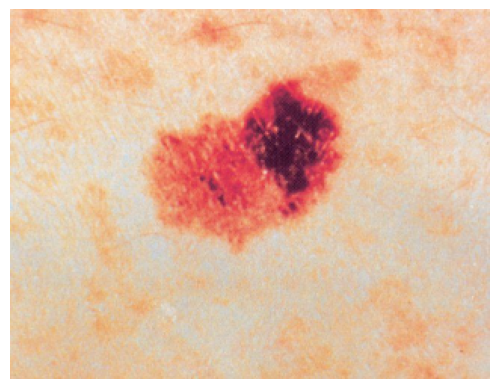

(245, 318, 3)

In [97]:
#this image is too big and clustering msy require time. Let's resize the image to half the dimension

img=cv2.resize(img, (w//2, h//2))
plt.imshow(img)
plt.axis('off')
plt.show()
img.shape


In [98]:
# Reshape it to be 2-dimension
X = img.reshape(img.shape[0] * img.shape[1], img.shape[2])
print(X.shape)

(77910, 3)


Let's apply the K-means clustering with K=10 so as to quantize the colors to only 10.

In [99]:
# Run the Kmeans algorithm
km = KMeans(n_clusters=2)
km.fit(X)

KMeans(n_clusters=2)

In [100]:
centroids = km.cluster_centers_
labels = km.labels_

print('centroids shape ', centroids.shape)
print('labels shape ', labels.shape)

centroids shape  (2, 3)
labels shape  (77910,)


In [101]:
# Use the centroids to quantize colors of the image
X_quantized = centroids[labels]
print('X quantized', X_quantized.shape)

X quantized (77910, 3)


In [102]:
# Put the quantized image in matrix form
X_quantized = X_quantized.reshape(img.shape[0], img.shape[1], img.shape[2])
print('reshaped ', X_quantized.shape)

reshaped  (245, 318, 3)


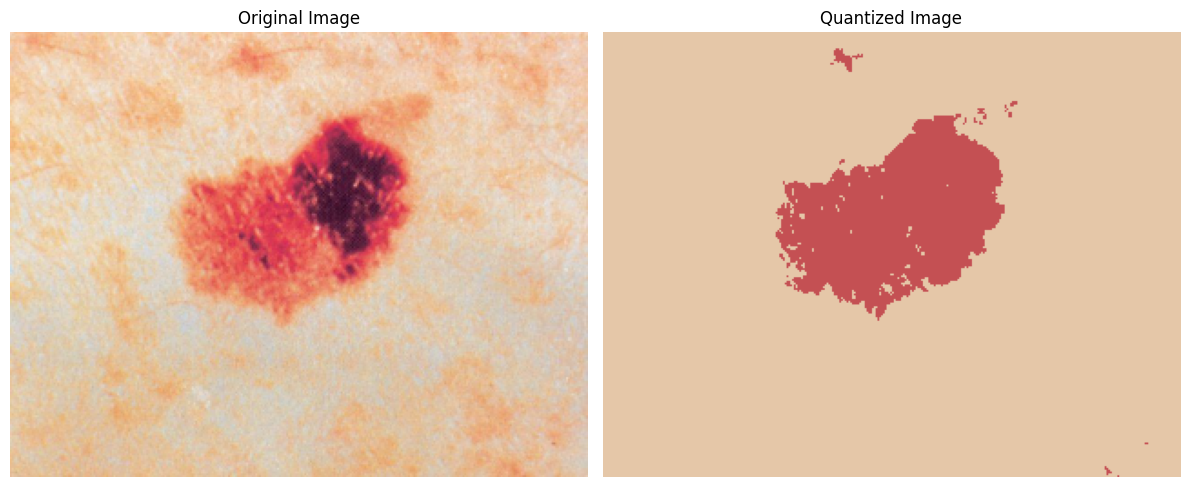

In [103]:
# Plot the original and the quantized image next to each other
fig, ax = plt.subplots(1, 2, figsize = (12, 8))
ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[1].imshow(X_quantized)
ax[1].set_title('Quantized Image')
for ax in fig.axes:
    ax.axis('off')
plt.tight_layout();